# Embeddings merging strategies analysis

In [1]:
import pandas as pd
import os
import numpy as np
from typing import Literal

In [2]:
base_path = "../"

#### Load data

In [3]:
df = pd.read_csv(os.path.join(base_path, "gridsearch_merging_strategy.csv"))
df.head()

,DNABERTBACTSTRAT,NT2PHAGESTRAT,NT2BACTSTRAT,MEGADNAPHAGESTRAT,DNABERTPHAGESTRAT,MEGADNABACTSTRAT,F1Score1,Average
0,TruncateStrategy,TruncateStrategy,TruncateStrategy,TfidfStrategy,Tf4idfStrategy,MaxStrategy,0.910256,0.9102
1,TruncateStrategy,TruncateStrategy,TruncateStrategy,MaxStrategy,Tf4idfStrategy,MaxStrategy,0.920198,0.9201
2,TruncateStrategy,TruncateStrategy,TruncateStrategy,MaxStrategy,TruncateStrategy,TruncateStrategy,0.923039,0.9230
3,TruncateStrategy,TruncateStrategy,TruncateStrategy,TruncateStrategy,MaxStrategy,TruncateStrategy,0.925735,0.9257
4,TruncateStrategy,TruncateStrategy,TruncateStrategy,TfidfStrategy,TruncateStrategy,Tf4idfStrategy,0.915788,0.9157


## Analysis

In [39]:
th_high = 0.94
th_low = 0.90
# th_high = 0.95
# th_low = 0.80

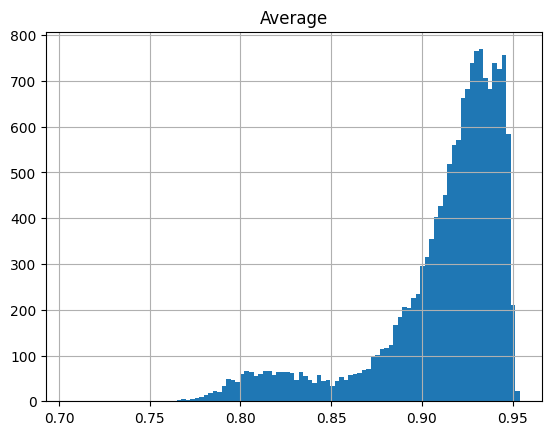

In [40]:
df.hist(column="Average", bins=100);

In [41]:
df.sort_values(axis=0, by="Average", ascending=False, inplace=True, ignore_index=True)
df.head()

,DNABERTBACTSTRAT,NT2PHAGESTRAT,NT2BACTSTRAT,MEGADNAPHAGESTRAT,DNABERTPHAGESTRAT,MEGADNABACTSTRAT,F1Score1,Average
0,MaxStrategy,TruncateStrategy,Tf4idfStrategy,TfidfStrategy,MaxStrategy,MaxStrategy,0.953854,0.9538
1,MaxStrategy,TruncateStrategy,TfidfStrategy,MaxStrategy,Tf4idfStrategy,MaxStrategy,0.953701,0.9537
2,MaxStrategy,TKPertStrategy,TruncateStrategy,TfidfStrategy,TKPertStrategy,TruncateStrategy,0.953565,0.9535
3,MaxStrategy,TfidfStrategy,TfidfStrategy,TKPertStrategy,TruncateStrategy,TruncateStrategy,0.953387,0.9533
4,MaxStrategy,TfidfStrategy,TruncateStrategy,TfidfStrategy,MaxStrategy,MaxStrategy,0.953267,0.9532


In [42]:
df_best = df[df["Average"] >= th_high]
print(f"Number of elements selected as bests: {len(df_best)}")

df_worse = df[df["Average"] < th_low]
print(f"Number of elements selected as worse: {len(df_worse)}")

Number of elements selected as bests: 2716
Number of elements selected as worse: 3778


In [43]:
DF_COLUMNS = ["NT2PHAGESTRAT", "MEGADNAPHAGESTRAT", "DNABERTPHAGESTRAT", "NT2BACTSTRAT", "MEGADNABACTSTRAT", "DNABERTBACTSTRAT"]
strategies = np.unique(df[DF_COLUMNS].values)

def make_pretty(styler, title: str, cmap: str = "RdYlGn", vmin = None, vmax = None, percentage: bool = False, axis: Literal[0] | None = 0):
    styler.set_caption(title)
    if percentage:
        styler.format(lambda x: f"{x*100:.2f}%" if np.isfinite(x) else x) # type: ignore
    else:
        styler.format(precision=3)
    styler.background_gradient(axis=axis, cmap=cmap, vmin=vmin, vmax=vmax)
    return styler


### Single column analysis

How many of each of them are in the top and bottom

In [44]:
table_best = pd.DataFrame(columns=DF_COLUMNS, index=strategies, dtype=float).fillna(0)
table_worse = pd.DataFrame(columns=DF_COLUMNS, index=strategies, dtype=float).fillna(0)

for column in DF_COLUMNS:
    table_best[column] = df_best[column].value_counts(normalize=True)
    table_worse[column] = df_worse[column].value_counts(normalize=True)

table_best.fillna(0, inplace=True)
table_worse.fillna(0, inplace=True)

In [45]:
table_best.style.pipe(make_pretty, title=f"Best strategies (f1 >= {th_high}: {len(df_best)} exps)", percentage=True)

,NT2PHAGESTRAT,MEGADNAPHAGESTRAT,DNABERTPHAGESTRAT,NT2BACTSTRAT,MEGADNABACTSTRAT,DNABERTBACTSTRAT
MaxStrategy,18.37%,20.54%,19.29%,35.64%,25.66%,30.34%
TKPertStrategy,22.39%,13.99%,23.97%,9.06%,15.21%,12.37%
Tf4idfStrategy,18.63%,21.83%,19.00%,8.98%,12.30%,15.57%
TfidfStrategy,18.67%,22.24%,18.15%,8.95%,12.08%,14.29%
TruncateStrategy,21.94%,21.39%,19.59%,37.37%,34.76%,27.43%


In [46]:
table_worse.style.pipe(make_pretty, title=f"Worse strategies (f1 < {th_low}: {len(df_worse)} exps)", cmap="RdYlGn_r", percentage=True)

,NT2PHAGESTRAT,MEGADNAPHAGESTRAT,DNABERTPHAGESTRAT,NT2BACTSTRAT,MEGADNABACTSTRAT,DNABERTBACTSTRAT
MaxStrategy,22.29%,22.82%,21.25%,4.92%,6.11%,7.81%
TKPertStrategy,17.39%,19.53%,18.58%,29.91%,20.20%,25.81%
Tf4idfStrategy,20.51%,17.97%,20.78%,29.83%,34.57%,28.96%
TfidfStrategy,20.86%,18.32%,20.51%,29.51%,35.36%,29.33%
TruncateStrategy,18.95%,21.36%,18.87%,5.82%,3.76%,8.10%


### Single column analysis

How many experiments for each category are in the top/bottom section

In [47]:
table_best_2 = pd.DataFrame(columns=DF_COLUMNS, index=strategies, dtype=float).fillna(0)
table_worse_2 = pd.DataFrame(columns=DF_COLUMNS, index=strategies, dtype=float).fillna(0)

for column in DF_COLUMNS:
    for strat in strategies:
        table_best_2.loc[strat, column] = len(df_best[df_best[column] == strat]) / len(df[df[column] == strat])
        table_worse_2.loc[strat, column] = len(df_worse[df_worse[column] == strat]) / len(df[df[column] == strat])

table_best_2.fillna(0, inplace=True)
table_worse_2.fillna(0, inplace=True)

In [48]:
table_best_2.style.pipe(make_pretty, title=f"Best strategies (f1 >= {th_high}: {len(df_best)} exps)", percentage=True, axis=None)

,NT2PHAGESTRAT,MEGADNAPHAGESTRAT,DNABERTPHAGESTRAT,NT2BACTSTRAT,MEGADNABACTSTRAT,DNABERTBACTSTRAT
MaxStrategy,15.97%,17.86%,16.77%,30.98%,22.30%,26.37%
TKPertStrategy,19.46%,12.16%,20.83%,7.87%,13.22%,10.75%
Tf4idfStrategy,16.19%,18.98%,16.51%,7.81%,10.69%,13.54%
TfidfStrategy,16.22%,19.33%,15.78%,7.78%,10.50%,12.42%
TruncateStrategy,19.07%,18.59%,17.02%,32.48%,30.21%,23.84%


In [49]:
table_worse_2.style.pipe(make_pretty, title=f"Worse strategies (f1 < {th_low}: {len(df_worse)} exps)", cmap="RdYlGn_r", percentage=True, axis=None)

,NT2PHAGESTRAT,MEGADNAPHAGESTRAT,DNABERTPHAGESTRAT,NT2BACTSTRAT,MEGADNABACTSTRAT,DNABERTBACTSTRAT
MaxStrategy,26.94%,27.58%,25.70%,5.95%,7.39%,9.44%
TKPertStrategy,21.02%,23.62%,22.46%,36.16%,24.42%,31.20%
Tf4idfStrategy,24.80%,21.73%,25.12%,36.06%,41.79%,35.01%
TfidfStrategy,25.22%,22.14%,24.80%,35.68%,42.75%,35.46%
TruncateStrategy,22.91%,25.82%,22.82%,7.04%,4.54%,9.79%


### Single column analysis: Average score for each strategy

In [16]:
weights_table = pd.DataFrame(columns=DF_COLUMNS, index=strategies, dtype=float).fillna(0)

for column in DF_COLUMNS:
    for strat in strategies:
        weights_table.loc[strat, column] = df[df[column] == strat]["Average"].mean()

weights_table.style.pipe(make_pretty, title="Average score", cmap="RdYlGn", vmin=0.86, vmax=0.95)

,NT2PHAGESTRAT,MEGADNAPHAGESTRAT,DNABERTPHAGESTRAT,NT2BACTSTRAT,MEGADNABACTSTRAT,DNABERTBACTSTRAT
MaxStrategy,0.908,0.910,0.910,0.929,0.925,0.925
TKPertStrategy,0.913,0.910,0.912,0.901,0.916,0.911
Tf4idfStrategy,0.910,0.913,0.911,0.898,0.892,0.897
TfidfStrategy,0.910,0.913,0.910,0.898,0.892,0.897
TruncateStrategy,0.913,0.910,0.912,0.929,0.930,0.925


In [17]:
weights_table = pd.DataFrame(columns=DF_COLUMNS, index=strategies, dtype=float).fillna(0)
df_top_bottom = df[(df["Average"] >= th_high) | (df["Average"] < th_low)]

for column in DF_COLUMNS:
    for strat in strategies:
        weights_table.loc[strat, column] = df_top_bottom[df_top_bottom[column] == strat]["Average"].mean()

weights_table.style.pipe(make_pretty, title="Average score (only top + bottom)", cmap="RdYlGn", vmin=0.86, vmax=0.95)

,NT2PHAGESTRAT,MEGADNAPHAGESTRAT,DNABERTPHAGESTRAT,NT2BACTSTRAT,MEGADNABACTSTRAT,DNABERTBACTSTRAT
MaxStrategy,0.890,0.893,0.892,0.935,0.930,0.929
TKPertStrategy,0.898,0.885,0.896,0.876,0.905,0.897
Tf4idfStrategy,0.893,0.898,0.894,0.869,0.866,0.869
TfidfStrategy,0.893,0.899,0.893,0.869,0.867,0.868
TruncateStrategy,0.897,0.894,0.896,0.933,0.937,0.927


## First round removal

In [ ]:
remaining_strats = {
    "NT2PHAGESTRAT": ["TruncateStrategy", "MaxStrategy", "TfidfStrategy", "Tf4idfStrategy", "TKPertStrategy"],
    "MEGADNAPHAGESTRAT": ["TruncateStrategy", "MaxStrategy", "TfidfStrategy", "Tf4idfStrategy", "TKPertStrategy"],
    "DNABERTPHAGESTRAT": ["TruncateStrategy", "MaxStrategy", "TfidfStrategy", "Tf4idfStrategy", "TKPertStrategy"],
    "NT2BACTSTRAT": ["TruncateStrategy", "MaxStrategy"],
    "MEGADNABACTSTRAT": ["TruncateStrategy", "MaxStrategy"],
    "DNABERTBACTSTRAT": ["TruncateStrategy", "MaxStrategy"],
}

In [51]:
ndf = df.copy()

for column, strats in remaining_strats.items():
    ndf.drop(ndf[ndf[column].map(lambda x: x not in strats)].index, inplace=True)

print(f"Total elements: {len(ndf)}")
ndf.head()

Total elements: 640


,DNABERTBACTSTRAT,NT2PHAGESTRAT,NT2BACTSTRAT,MEGADNAPHAGESTRAT,DNABERTPHAGESTRAT,MEGADNABACTSTRAT,F1Score1,Average
2,MaxStrategy,TKPertStrategy,TruncateStrategy,TfidfStrategy,TKPertStrategy,TruncateStrategy,0.953565,0.9535
4,MaxStrategy,TfidfStrategy,TruncateStrategy,TfidfStrategy,MaxStrategy,MaxStrategy,0.953267,0.9532
6,MaxStrategy,TKPertStrategy,TruncateStrategy,Tf4idfStrategy,Tf4idfStrategy,MaxStrategy,0.953001,0.9530
11,MaxStrategy,TKPertStrategy,TruncateStrategy,MaxStrategy,MaxStrategy,MaxStrategy,0.952369,0.9523
14,MaxStrategy,TruncateStrategy,TruncateStrategy,TfidfStrategy,TruncateStrategy,MaxStrategy,0.952001,0.9520


Number of elements selected as bests: 126
Number of elements selected as worse: 104


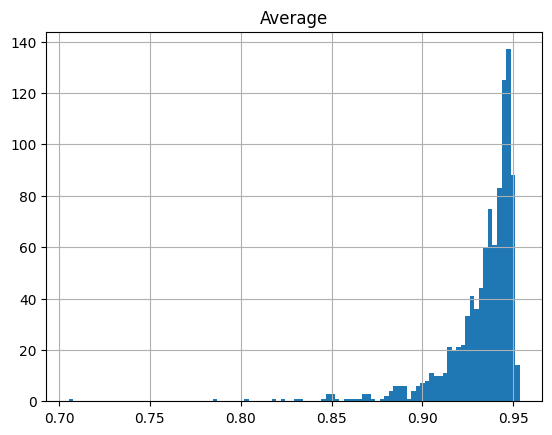

In [20]:
nth_high = 0.948
nth_low = 0.91

ndf_best = ndf[ndf["Average"] >= nth_high]
print(f"Number of elements selected as bests: {len(ndf_best)}")

ndf_worse = ndf[ndf["Average"] < nth_low]
print(f"Number of elements selected as worse: {len(ndf_worse)}")

ndf.hist(column="Average", bins=100);

### Single column analysis

How many of each of them are in the top and bottom

In [21]:
ntable_best = pd.DataFrame(columns=DF_COLUMNS, index=strategies, dtype=float).fillna(0)
ntable_worse = pd.DataFrame(columns=DF_COLUMNS, index=strategies, dtype=float).fillna(0)

for column in DF_COLUMNS:
    ntable_best[column] = ndf_best[column].value_counts(normalize=True)
    ntable_worse[column] = ndf_worse[column].value_counts(normalize=True)

In [22]:
ntable_best.style.pipe(make_pretty, title=f"Best strategies (f1 >= {nth_high}: {len(ndf_best)} exps)", percentage=True)

,NT2PHAGESTRAT,MEGADNAPHAGESTRAT,DNABERTPHAGESTRAT,NT2BACTSTRAT,MEGADNABACTSTRAT,DNABERTBACTSTRAT
MaxStrategy,17.46%,26.19%,17.46%,34.13%,49.21%,76.19%
TKPertStrategy,28.57%,11.90%,17.46%,nan,nan,nan
Tf4idfStrategy,11.90%,26.19%,21.43%,nan,nan,nan
TfidfStrategy,22.22%,22.22%,21.43%,nan,nan,nan
TruncateStrategy,19.84%,13.49%,22.22%,65.87%,50.79%,23.81%


In [23]:
ntable_worse.style.pipe(make_pretty, title=f"Worse strategies (f1 < {nth_low}: {len(ndf_worse)} exps)", cmap="RdYlGn_r", percentage=True)

,NT2PHAGESTRAT,MEGADNAPHAGESTRAT,DNABERTPHAGESTRAT,NT2BACTSTRAT,MEGADNABACTSTRAT,DNABERTBACTSTRAT
MaxStrategy,22.12%,17.31%,23.08%,52.88%,62.50%,56.73%
TKPertStrategy,13.46%,23.08%,4.81%,nan,nan,nan
Tf4idfStrategy,24.04%,14.42%,20.19%,nan,nan,nan
TfidfStrategy,24.04%,13.46%,29.81%,nan,nan,nan
TruncateStrategy,16.35%,31.73%,22.12%,47.12%,37.50%,43.27%


### Single column analysis

How many experiments for each category are in the top/bottom section

In [24]:
ntable_best_2 = pd.DataFrame(columns=DF_COLUMNS, index=strategies, dtype=float).fillna(0)
ntable_worse_2 = pd.DataFrame(columns=DF_COLUMNS, index=strategies, dtype=float).fillna(0)

for column in DF_COLUMNS:
    for strat in strategies:
        ntable_best_2.loc[strat, column] = len(ndf_best[ndf_best[column] == strat]) / len(ndf[ndf[column] == strat]) if len(ndf[ndf[column] == strat]) != 0 else np.nan
        ntable_worse_2.loc[strat, column] = len(ndf_worse[ndf_worse[column] == strat]) / len(ndf[ndf[column] == strat]) if len(ndf[ndf[column] == strat]) != 0 else np.nan

In [25]:
ntable_best_2.style.pipe(make_pretty, title=f"Best strategies (f1 >= {nth_high}: {len(ndf_best)} exps)", percentage=True, axis=None)

,NT2PHAGESTRAT,MEGADNAPHAGESTRAT,DNABERTPHAGESTRAT,NT2BACTSTRAT,MEGADNABACTSTRAT,DNABERTBACTSTRAT
MaxStrategy,11.00%,16.50%,11.00%,8.60%,12.40%,19.20%
TKPertStrategy,18.00%,7.50%,11.00%,nan,nan,nan
Tf4idfStrategy,7.50%,16.50%,13.50%,nan,nan,nan
TfidfStrategy,14.00%,14.00%,13.50%,nan,nan,nan
TruncateStrategy,12.50%,8.50%,14.00%,16.60%,12.80%,6.00%


In [26]:
ntable_worse_2.style.pipe(make_pretty, title=f"Worse strategies (f1 < {nth_low}: {len(ndf_worse)} exps)", cmap="RdYlGn_r", percentage=True, axis=None)

,NT2PHAGESTRAT,MEGADNAPHAGESTRAT,DNABERTPHAGESTRAT,NT2BACTSTRAT,MEGADNABACTSTRAT,DNABERTBACTSTRAT
MaxStrategy,11.50%,9.00%,12.00%,11.00%,13.00%,11.80%
TKPertStrategy,7.00%,12.00%,2.50%,nan,nan,nan
Tf4idfStrategy,12.50%,7.50%,10.50%,nan,nan,nan
TfidfStrategy,12.50%,7.00%,15.50%,nan,nan,nan
TruncateStrategy,8.50%,16.50%,11.50%,9.80%,7.80%,9.00%
